In [1]:
import cv2
import os 
from collections import defaultdict
from PIL import Image
import math
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TABLEAU_COLORS
import re

helper functions

In [2]:


# --- CONSTANTS & HELPER FUNCTIONS ---

LABEL_MAP = {
    1: "Starfish", 2: "Crab", 3: "Black goby", 4: "Wrasse", 
    5: "Two-spotted goby", 6: "Cod", 7: "Painted goby", 8: "Sand eel", 
    9: "Whiting"
}

BRIGHT_COLORS = [
    '#FF3333',  # Bright Red
    '#33CC33',  # Bright Green
    '#3366FF',  # Bright Blue
    '#FFCC33',  # Bright Yellow/Orange
    '#CC33FF',  # Bright Purple
    '#33FFFF',  # Cyan
    '#FF6600',  # Orange
    '#993300',  # Dark Brown
    '#330066',  # Indigo
    '#FF99FF'   # Pink
]

def extract_class_from_path(path):
    """
    Extract the single digit class ID (1-9) immediately preceded by an underscore 
    and followed by the file extension.
    """
    filename = os.path.basename(path)
    # Regex: find a single digit (\d) that is preceded by '_' and followed 
    # by a dot and the extension.
    match = re.search(r"\_(\d)(?=\.[^\.]*$)", filename, flags=re.IGNORECASE)
    
    if not match:
        return -1 
    return int(match.group(1))

# --- 1. NEW EXTRACTION FUNCTION ---

def extract_area_by_class(directory_path):
    """
    Iterates through images in a directory, calculates the area, and groups 
    the areas by the class ID extracted from the filename.
    
    Returns:
        dict: {class_id (int): [list_of_areas (int)]}
    """
    print(f"1. Extracting area data from files in: {directory_path}")
    area_by_class = defaultdict(list)
    
    for filename in os.listdir(directory_path):
        # Skip system files
        if filename.startswith('.'):
            continue

        full_path = os.path.join(directory_path, filename)
        
        # Check if it's a file and not a directory
        if not os.path.isfile(full_path):
            continue
            
        class_id = extract_class_from_path(full_path)
        
        # Only process files with a valid class ID (1-9)
        if class_id not in LABEL_MAP:
            # print(f"Skipping file {filename}: Invalid class ID.")
            continue
            
        try:
            img = Image.open(full_path)
            width, height = img.size
            area = width * height
            
            area_by_class[class_id].append(area)
            
        except Exception as e:
            print(f"Skipping file {filename} due to error: {e}")

    print(f"   ✅ Data extracted for {len(area_by_class)} classes.")
    return area_by_class

# --- 2. NEW PLOTTING FUNCTION ---


In [3]:
DATA_DIRECTORY = "../data" 

area_data = extract_area_by_class(DATA_DIRECTORY)

1. Extracting area data from files in: ../data
   ✅ Data extracted for 9 classes.


Checking the max value we need to set the x axis limit

In [4]:
for i in range(1,10):
    print(LABEL_MAP[i])
    print(f"max:{max(area_data[i])}")
    print(f"average: {round(np.mean(area_data[i]),2)} ")
    print(f"min: {min(area_data[i])}")


Starfish
max:39216
average: 3162.7 
min: 216
Crab
max:740370
average: 12501.97 
min: 798
Black goby
max:51680
average: 8863.85 
min: 720
Wrasse
max:1438815
average: 34632.5 
min: 812
Two-spotted goby
max:99760
average: 2495.22 
min: 275
Cod
max:600066
average: 37391.25 
min: 1248
Painted goby
max:36358
average: 4050.61 
min: 957
Sand eel
max:320100
average: 16398.73 
min: 1040
Whiting
max:342216
average: 38929.43 
min: 2210


First is the 3x3 histograms of each class distribution

In [5]:
def plot_area_histograms_by_class(area_by_class_dict, N_BINS=50):
    """
    Plots a histogram of image area for each class in a multi-subplot layout.
    
    The plot will use a logarithmic X-axis for better visualization of area ranges.
    
    FIXED: X-axis limit of 2,000,000 and visible X/Y tick labels on all plots.
    """
    
    if not area_by_class_dict:
        print("Error: Area by class dictionary is empty. Cannot plot.")
        return

    # Prepare all data for global min/max calculation and bin definition
    all_areas = np.concatenate([areas for areas in area_by_class_dict.values()])

    if all_areas.size == 0:
        print("Error: Combined area data is empty. Cannot plot.")
        return

    # Define the FIXED X-AXIS UPPER LIMIT (2,000,000)
    MAX_X_LIMIT = 2000000 

    # Define global logarithmic bins (up to the max area or the new limit)
    # The maximum bin edge should be the smaller of the data max or the imposed limit
    min_area = np.min(all_areas[all_areas > 0])
    max_data_area = np.max(all_areas)
    effective_max_area = min(max_data_area, MAX_X_LIMIT) # Bins only need to go up to the limit

    # Define bins using the full data range, but cap the max for the logspace
    # We use MAX_X_LIMIT as the highest potential bin edge to ensure coverage up to the limit
    bin_edges = np.logspace(np.log10(min_area), np.log10(MAX_X_LIMIT), N_BINS + 1)
    
    # Determine subplot layout
    unique_classes = sorted(area_by_class_dict.keys())
    n_rows = 3
    n_cols = 3
    
    # *** KEY CHANGE 1: sharex=False ***
    # This allows each subplot to control its own ticks and labels
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15), sharex=False, sharey=False)
    fig.suptitle("Image Area Distribution per Class (Logarithmic X-Axis)", fontsize=16, y=1.02)
    
    # Generate the log ticks for the X-axis, up to the fixed limit
    start_power = int(np.floor(np.log10(min_area)))
    # We want ticks up to and including the 10^6 (1,000,000) tick. 
    # If the limit is 2M, the next full power of 10 is 10M, which is too high.
    # We will manually add the limit if it is not a power of 10.
    end_power = int(np.floor(np.log10(MAX_X_LIMIT))) # Go up to the largest power of 10 below the limit
    
    log_ticks = [10**i for i in range(start_power, end_power + 1)]
    
    # Add the explicit limit if it's not already a power of 10 tick
    if MAX_X_LIMIT not in log_ticks:
        log_ticks.append(MAX_X_LIMIT)
        
    log_labels = [f'{t:,}' for t in log_ticks]
    
    # Iterate through classes and plot
    for i, cls in enumerate(unique_classes):
        row = i // n_cols
        col = i % n_cols
        ax = axes.flatten()[i] # Use flatten for easier indexing regardless of n_rows/n_cols
        
        areas = area_by_class_dict[cls]
        
        if len(areas) == 0:
            ax.set_title(f"Class {cls} ({LABEL_MAP.get(cls, 'Unknown')})\nNo Data", fontsize=10)
            ax.axis('off') # Hide empty plot
            continue
            
        # Plot histogram - np.clip ensures data beyond limit is counted in the last bin
        clipped_areas = np.clip(areas, a_min=None, a_max=MAX_X_LIMIT)

        ax.hist(
            clipped_areas, 
            bins=bin_edges, # Use the bins defined up to the MAX_X_LIMIT
            edgecolor='black', 
            alpha=0.8, 
            color='purple'
        )
        
        # Set logarithmic scale
        ax.set_xscale('log')
        
        
        ax.set_xlim(left=min_area, right=MAX_X_LIMIT)
        
        
        ax.set_xticks(log_ticks)
        ax.set_xticklabels(log_labels, rotation=45, ha='right', fontsize=8)
        ax.set_xlabel("Area (Pixels)", fontsize=10)
        
        ax.set_title(f"Class {cls}: {LABEL_MAP.get(cls, 'Unknown')} (N={len(areas)})", fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        
        ax.set_ylabel("Frequency", fontsize=10)
    
    # Turn off any unused subplots
    for i in range(len(unique_classes), n_rows * n_cols):
        fig.delaxes(axes.flatten()[i])
        
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
    
    output_path = "image_area_histograms_by_class.png"
    plt.savefig(output_path)
    print(f"\n✅ Multi-histogram saved to: {output_path}")




✅ Multi-histogram saved to: image_area_histograms_by_class.png


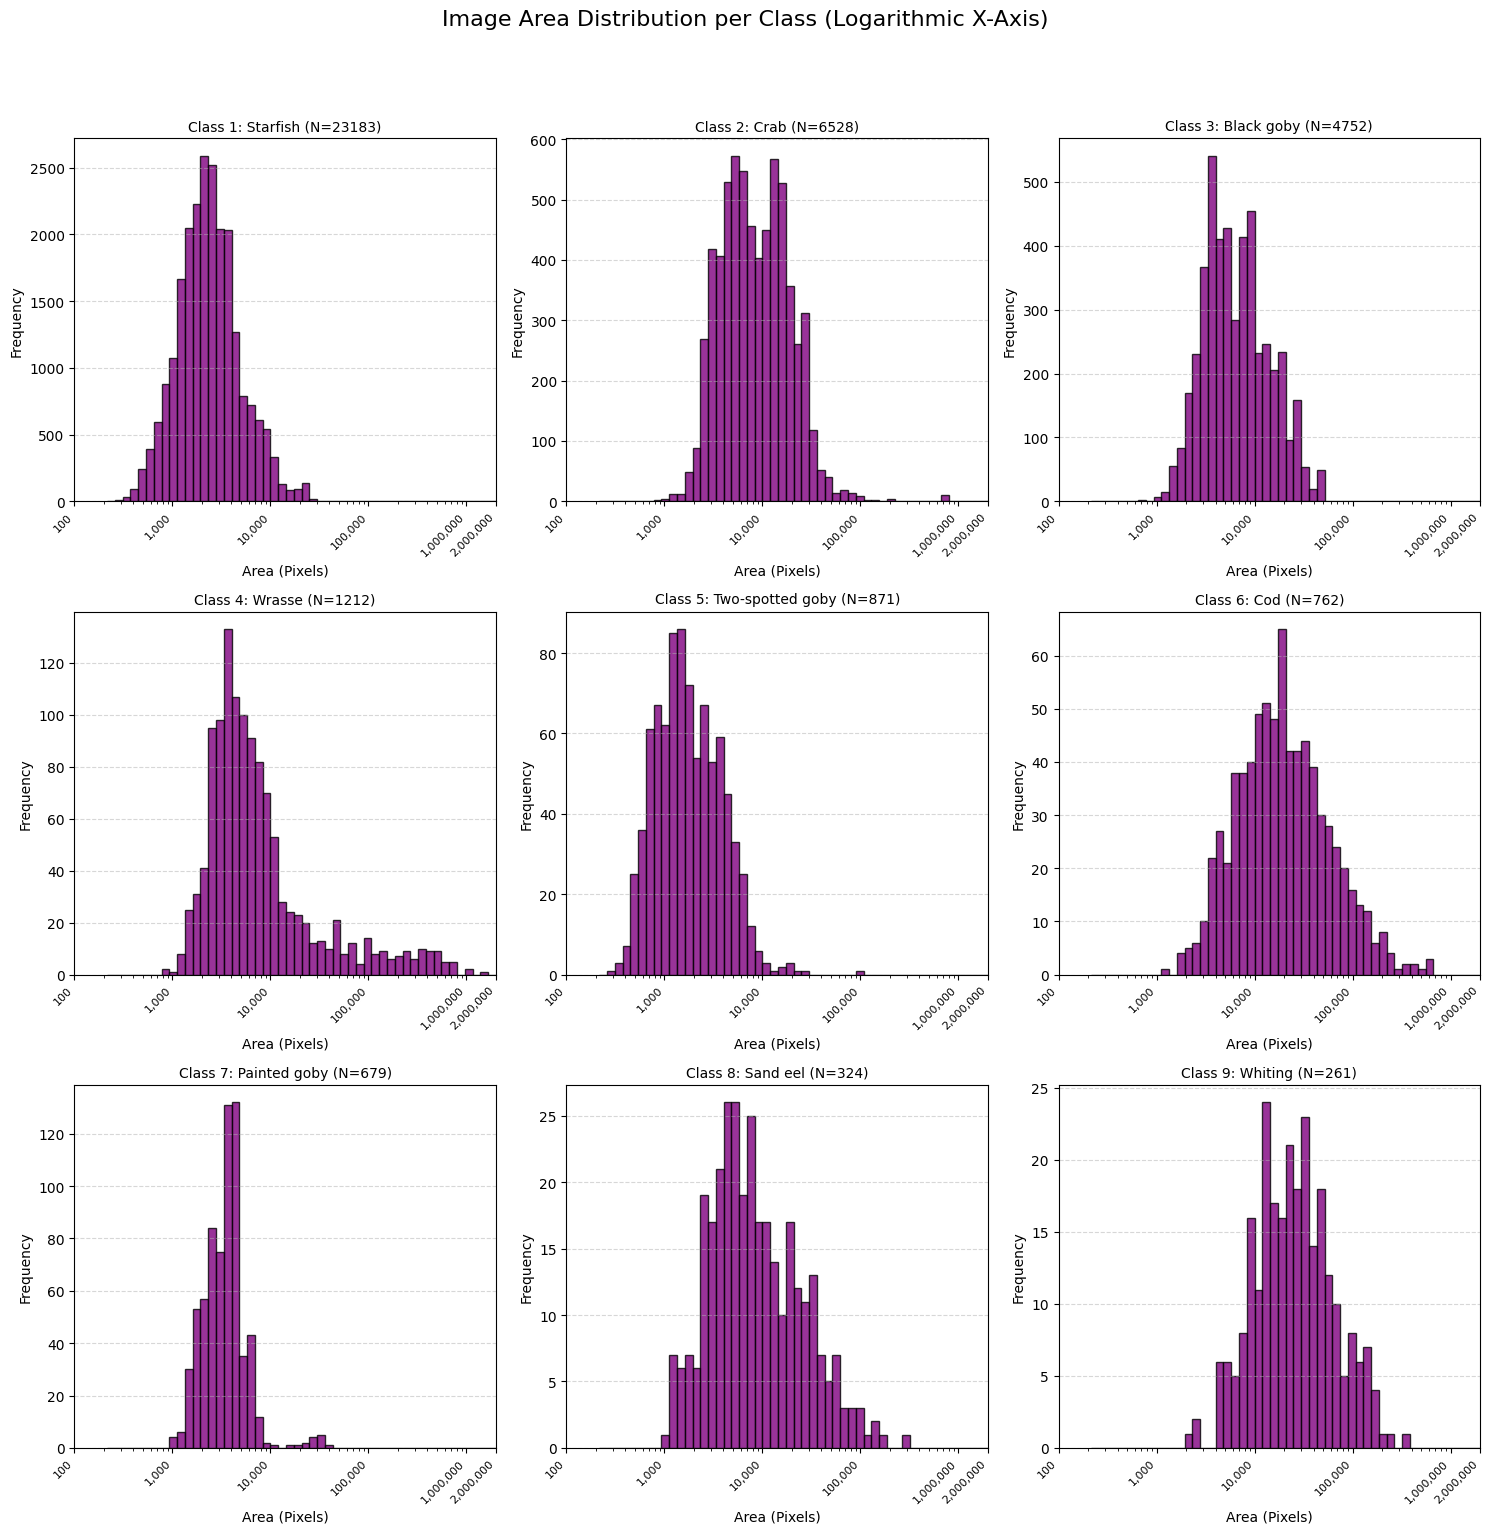

In [6]:

# 2. Plot the results
plot_area_histograms_by_class(area_data)
    

In [7]:



def plot_area_histograms_by_class_comparative(area_by_class_dict, N_BINS=50):
    """
    Plots a histogram of image area for each class in a multi-subplot layout, 
    sharing both X and Y axes for direct comparison, and using bright colors.
    """
    
    if not area_by_class_dict:
        print("Error: Area by class dictionary is empty. Cannot plot.")
        return

    # Prepare all data for global min/max calculation and bin definition
    all_areas = np.concatenate([areas for areas in area_by_class_dict.values()])
    if all_areas.size == 0:
        print("Error: Combined area data is empty. Cannot plot.")
        return
    MAX_X_LIMIT = 2000000

    # Define global logarithmic bins (ensures all subplots use the same X-scale)
    min_area = np.min(all_areas[all_areas > 0])
    max_area = np.max(all_areas)
    
    bin_edges = np.logspace(np.log10(min_area), np.log10(MAX_X_LIMIT), N_BINS + 1)
    
    # Determine subplot layout
    unique_classes = sorted(area_by_class_dict.keys())
    # Determine the number of rows/cols needed (e.g., 3x3 for 9 classes)
    n_classes = len(unique_classes)
    n_cols = int(np.ceil(np.sqrt(n_classes)))
    n_rows = int(np.ceil(n_classes / n_cols))
    
    
    # *** KEY CHANGE 1: sharey=True ***
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15), sharex=True, sharey=True)
    fig.suptitle("Comparative Image Area Distribution per Class (Shared X and Y Axes)", fontsize=16, y=1.02)
    
    # Generate the log ticks for shared X-axis
    start_power = int(np.floor(np.log10(min_area)))
    end_power = int(np.floor(np.log10(MAX_X_LIMIT)))
    log_ticks = [10**i for i in range(start_power, end_power + 1)]
    if MAX_X_LIMIT not in log_ticks:
        log_ticks.append(MAX_X_LIMIT)
    log_labels = [f'{t:,}' for t in log_ticks]
    
    # Flatten axes array for easier iteration if it's multidimensional
    axes_flat = axes.flatten()

    # Iterate through classes and plot
    for i, cls in enumerate(unique_classes):
        # Use the class ID to select a distinct color from the bright palette
        color_index = cls % len(BRIGHT_COLORS)
        plot_color = BRIGHT_COLORS[color_index]
        
        ax = axes_flat[i]
        areas = area_by_class_dict[cls]
        
        if not areas:
            ax.set_title(f"Class {cls} ({LABEL_MAP.get(cls, 'Unknown')})\nNo Data (N=0)", fontsize=10)
            ax.axis('off') # Hide empty plot
            continue
            
        # Plot histogram
        ax.hist(
            areas, 
            bins=bin_edges, 
            edgecolor='black', 
            alpha=0.9, 
            # *** KEY CHANGE 2: Use bright, class-specific color ***
            color=plot_color
        )
        
        
        ax.set_xscale('log')
        ax.set_xlim(left=min_area, right=MAX_X_LIMIT)
        
        # Set consistent log ticks only on the bottom row for readability
        
        ax.set_xticks(log_ticks)
        ax.set_xticklabels(log_labels, rotation=45, ha='right', fontsize=8)
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
        ax.set_xlabel("Area (Pixels) [Log Scale]", fontsize=10)
        


        ax.set_title(f"Class {cls}: {LABEL_MAP.get(cls, 'Unknown')} (N={len(areas)})", fontsize=10, color=plot_color)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        
        ax.set_ylabel("Frequency", fontsize=10)
        
    
    # Turn off any unused subplots
    for i in range(len(unique_classes), n_rows * n_cols):
        fig.delaxes(axes_flat[i])
        
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
    
    output_path = "image_area_histograms_by_class_comparative.png"
    plt.savefig(output_path)
    print(f"\n✅ Comparative multi-histogram saved to: {output_path}")



✅ Comparative multi-histogram saved to: image_area_histograms_by_class_comparative.png


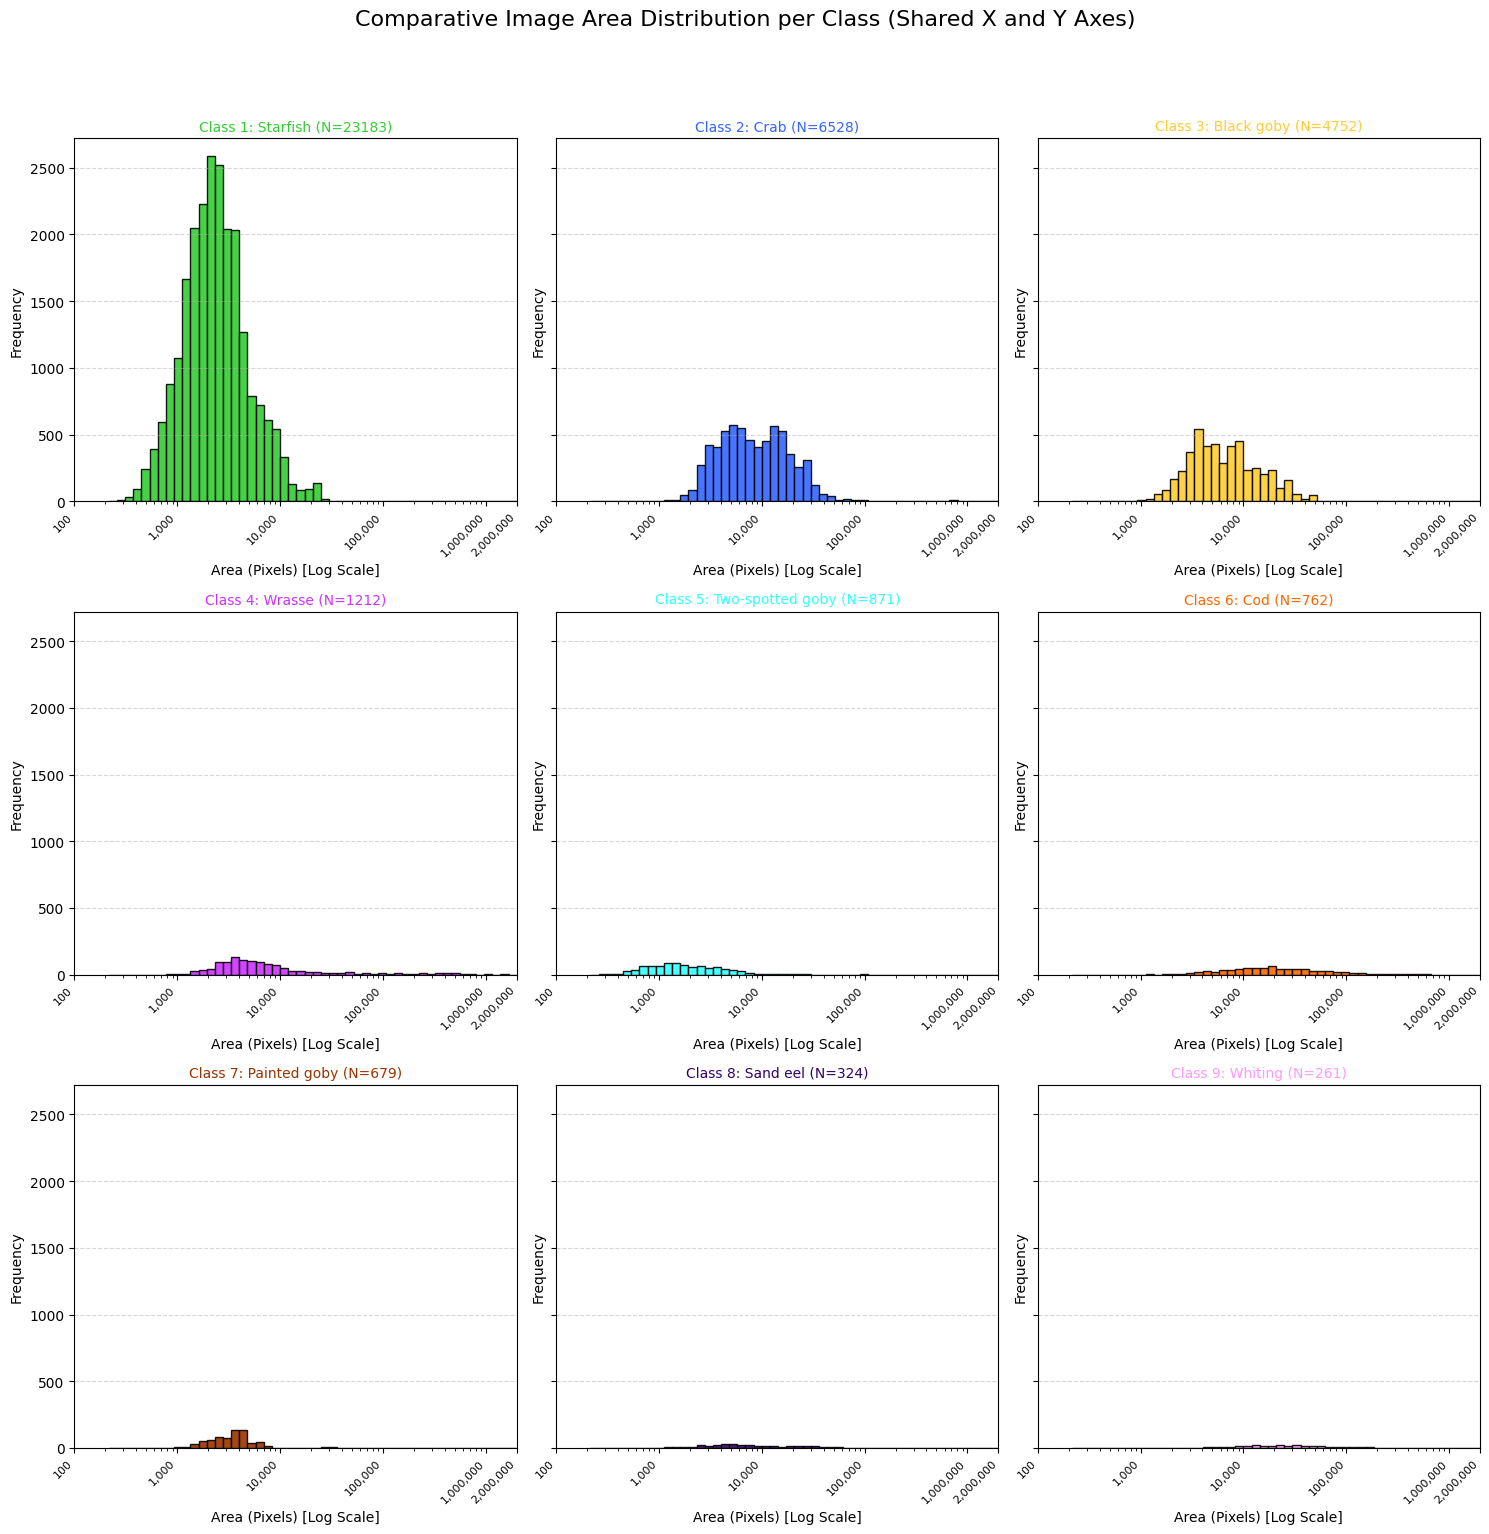

In [8]:


# 2. Plot the results
plot_area_histograms_by_class_comparative(area_data)
        

In [9]:



def plot_overlapping_area_histograms_by_class(area_by_class_dict, N_BINS=50, USE_LOG_SCALE=True):
    """
    Plots the image area distribution for all classes on a single, overlapping histogram 
    with transparency, using a logarithmic X-axis.
    
    Args:
        area_by_class_dict (dict): {class_id (int): [list_of_areas (int)]}
        N_BINS (int): Number of bins for the histogram.
        USE_LOG_SCALE (bool): If True, plots the x-axis (Area) on a logarithmic scale.
    """
    
    if not area_by_class_dict:
        print("Error: Area by class dictionary is empty. Cannot plot.")
        return

    # 1. PREPARE DATA AND COLORS
    
    # Use a set of distinct colors for the classes
    colors = BRIGHT_COLORS 
    
    # Prepare lists for plotting and legend labels
    all_areas_data = []
    plot_labels = []
    
    unique_classes = sorted(area_by_class_dict.keys())

    for i, cls in enumerate(unique_classes):
        areas = area_by_class_dict[cls]
        
        if areas:
            all_areas_data.append(np.array(areas))
            plot_labels.append(f"Class {cls}: {LABEL_MAP.get(cls, 'Unknown')} (N={len(areas)})")
        else:
            # Skip classes with no data
            continue
            
    # Combine all data to determine the global min/max for uniform binning
    combined_data = np.concatenate(all_areas_data)
    
    if combined_data.size == 0:
        print("Error: Combined area data is empty. Cannot plot.")
        return
        
    # 2. DEFINE UNIFORM BINS (Critical for overlap comparison)
    
    if USE_LOG_SCALE:
        min_area = np.min(combined_data[combined_data > 0]) # Ensure > 0 for log
        max_area = np.max(combined_data)
        bin_edges = np.logspace(np.log10(min_area), np.log10(max_area), N_BINS + 1)
        x_label = "Image Area (Pixels) [Log Scale]"
    else:
        min_val = np.min(combined_data)
        max_val = np.max(combined_data)
        bin_edges = np.linspace(min_val, max_val, N_BINS + 1)
        x_label = "Image Area (Pixels)"
    
    
    # 3. PLOTTING
    
    plt.figure(figsize=(14, 8))
    
    # Plot the overlapping histograms
    plt.hist(
        all_areas_data,
        bins=bin_edges,             # Use the global bins
        label=plot_labels,
        color=[colors[i % len(BRIGHT_COLORS)] for i in range(len(all_areas_data))], # Use colors based on order
        #alpha=0.6,                  # Use high transparency to show overlap
        edgecolor='black'            # Optional: helps distinguish bins
    )

    # 4. FORMATTING
    
    if USE_LOG_SCALE:
        plt.xscale('log')
        
        # Add informative log ticks (powers of 10)
        ax = plt.gca()
        MAX_X_LIMIT = 2000000
        start_power = int(np.floor(np.log10(min_area)))
        end_power = int(np.floor(np.log10(MAX_X_LIMIT)))
        log_ticks = [10**i for i in range(start_power, end_power + 1)]
        if MAX_X_LIMIT not in log_ticks:
            log_ticks.append(MAX_X_LIMIT)
        log_labels = [f'{t:,}' for t in log_ticks]
        
        if len(log_ticks) <= 15:
            ax.set_xticks(log_ticks)
            ax.set_xticklabels(log_labels, rotation=45, ha='right', fontsize=9)
        else:
            plt.xticks(rotation=45, ha='right', fontsize=9)
    else:
        plt.xticks(rotation=45, ha='right', fontsize=9)

    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("Frequency (Count of Images)", fontsize=12)
    plt.title("Overlapping Image Area Distributions by Class", fontsize=16)
    plt.legend(loc='upper right', fontsize=10, title="Class Distributions")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # 5. SAVE
    output_filename = "overlapping_area_histograms_all_classes.png"
    plt.savefig(output_filename)
    print(f"\n✅ Overlapping histogram saved to: {output_filename}")

# --- EXAMPLE USAGE ---


now this is one plot for all the data


✅ Overlapping histogram saved to: overlapping_area_histograms_all_classes.png


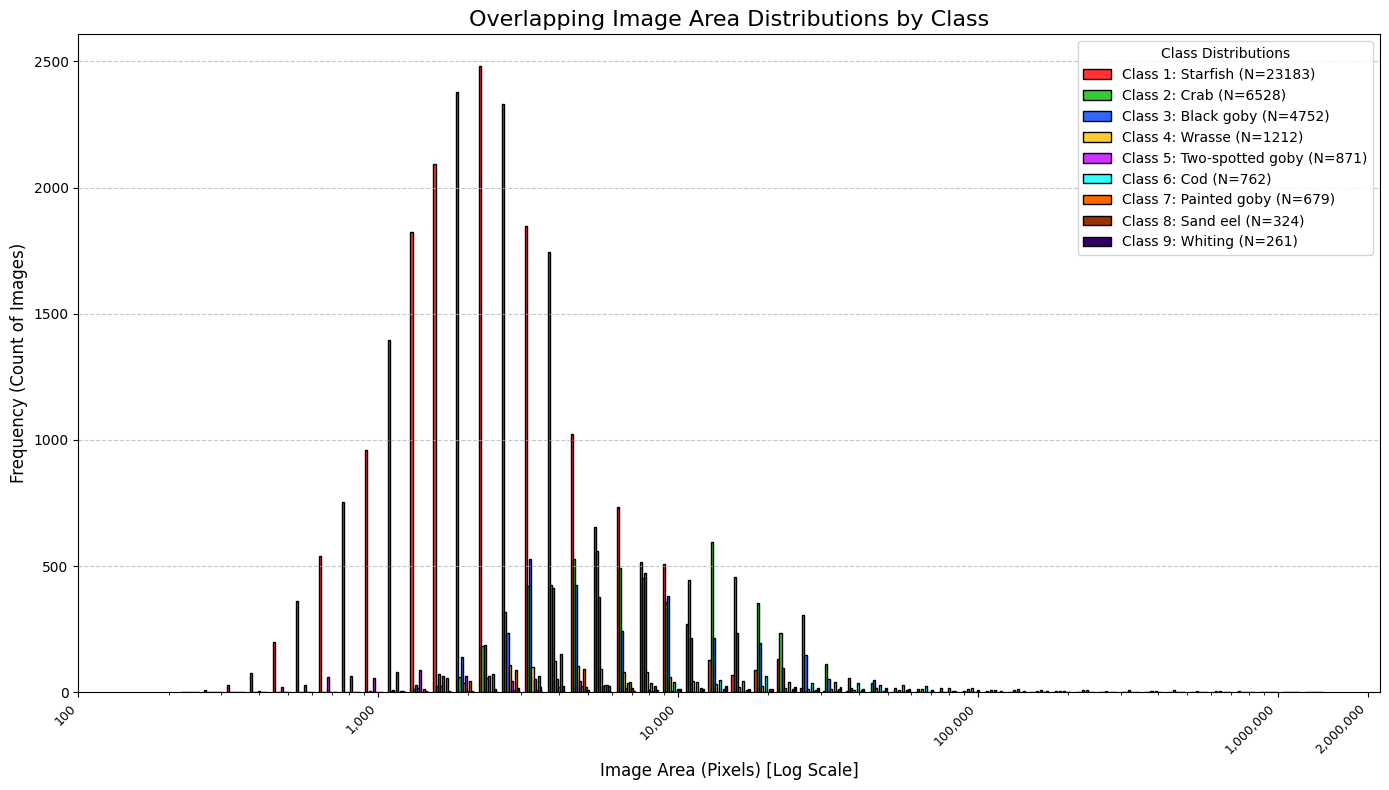

In [10]:
plot_overlapping_area_histograms_by_class(area_data)
        


# now for the kept and filtered per class

In [11]:


# --- CONSTANTS & HELPER FUNCTIONS ---


BRIGHT_COLORS_K_F = [
    '#33CC33',  # Bright Green (KEPT)
    '#FF3333',  # Bright Red (DELETED)
]

def extract_class_from_path(path):
    """
    Extract the single digit class ID (1-9) immediately preceded by an underscore 
    and followed by the file extension.
    """
    filename = os.path.basename(path)
    match = re.search(r"\_(\d)(?=\.[^\.]*$)", filename, flags=re.IGNORECASE)
    
    if not match:
        return -1 
    return int(match.group(1))


# --- 1. NEW EXTRACTION FUNCTION ---

def extract_filtered_areas(kept_paths_file, deleted_paths_file):
    """
    Reads image paths from 'kept' and 'deleted' files, calculates the area 
    for each, and groups the areas by class ID and filtering status.
    
    Returns:
        dict: {class_id (int): {'kept': [areas], 'deleted': [areas]}}
    """
    print("1. Extracting area data from filtered image path files...")
    
    # Initialize the nested dictionary
    area_data = defaultdict(lambda: {'kept': [], 'deleted': []})

    def process_file_list(file_path, status):
        """Helper function to read paths and calculate area."""
        count = 0
        try:
            with open(file_path, 'r') as f:
                image_paths = [line.strip() for line in f if line.strip()]
        except FileNotFoundError:
            print(f"   Warning: File not found at {file_path}. Skipping {status} data.")
            return

        for path in image_paths:
            if not os.path.exists(path):
                # print(f"   Skipping path (does not exist): {path}")
                continue

            class_id = extract_class_from_path(path)
            if class_id not in LABEL_MAP:
                continue

            try:
                img = Image.open(path)
                width, height = img.size
                area = width * height
                area_data[class_id][status].append(area)
                count += 1
            except Exception as e:
                print(f"   Skipping image {os.path.basename(path)} due to error: {e}")
        
        print(f"   Processed {count} {status} images.")

    process_file_list(kept_paths_file, 'kept')
    process_file_list(deleted_paths_file, 'deleted')
    
    return area_data


In [12]:

KEPT_PATHS_FILE_MAHALA = "../mahala_median/kept_image_paths.txt"
DELETED_PATHS_FILE_MAHALA = "../mahala_median/filtered_out_image_paths.txt"
# -------------------------------------------

# 1. Extract and process the area data
area_data_by_status_mahala = extract_filtered_areas(KEPT_PATHS_FILE_MAHALA, DELETED_PATHS_FILE_MAHALA)


1. Extracting area data from filtered image path files...
   Processed 29047 kept images.
   Processed 9525 deleted images.


In [13]:

KEPT_PATHS_FILE_EU = "../euclidean_median/kept_image_paths.txt"
DELETED_PATHS_FILE_EU = "../euclidean_median/filtered_out_image_paths.txt"
    # -------------------------------------------
area_data_by_status_eu = extract_filtered_areas(KEPT_PATHS_FILE_EU, DELETED_PATHS_FILE_EU)

    

1. Extracting area data from filtered image path files...
   Processed 20110 kept images.
   Processed 10767 deleted images.


In [26]:


# --- 2. MODIFIED PLOTTING FUNCTION ---

def plot_filtered_area_histograms(area_data,filter_type, N_BINS=50, USE_LOG_SCALE=True):
    """
    Plots the overlapping area histograms of kept vs. deleted images for each class.
    
    This function uses a multi-subplot layout with shared X and Y axes.
    """
    
    unique_classes = sorted(area_data.keys())
    if not unique_classes:
        print("Error: No data found for plotting.")
        return

    # 2a. Determine Global Bins and Y-Axis Max
    all_areas = []
    max_frequency = 0
    
    # Calculate all areas and find the maximum bin height across all plots
    for cls in unique_classes:
        kept_areas = np.array(area_data[cls]['kept'])
        deleted_areas = np.array(area_data[cls]['deleted'])
        
        if kept_areas.size > 0 or deleted_areas.size > 0:
            all_areas.append(np.concatenate([kept_areas, deleted_areas]))

    if not all_areas:
         print("Error: Combined area data is empty. Cannot plot.")
         return
         
    combined_data = np.concatenate(all_areas)

    # Define Global Logarithmic Bins (Shared X-axis)
    min_area = np.min(combined_data[combined_data > 0])
    max_area = np.max(combined_data)
    bin_edges = np.logspace(np.log10(min_area), np.log10(max_area), N_BINS + 1)
    
    # Determine the global max frequency (Y-axis max)
    for cls in unique_classes:
        kept_areas = area_data[cls]['kept']
        deleted_areas = area_data[cls]['deleted']
        
        if kept_areas or deleted_areas:
            # We must calculate the histogram counts to find the max frequency
            kept_hist, _ = np.histogram(kept_areas, bins=bin_edges)
            deleted_hist, _ = np.histogram(deleted_areas, bins=bin_edges)
            
            # Since they are overlapping, the highest bar height is the max of the two
            current_max = max(kept_hist.max(), deleted_hist.max())
            if current_max > max_frequency:
                max_frequency = current_max


    # 2b. Set up Subplots
    n_classes = len(unique_classes)
    n_cols = int(np.ceil(np.sqrt(n_classes)))
    n_rows = int(np.ceil(n_classes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15), sharex=True, sharey=False)
    fig.suptitle(f"Area Distribution: Kept vs. Filtered Out (Per Class) {filter_type}", fontsize=16, y=1.02)
    axes_flat = axes.flatten()

    # Define X-Axis Ticks
    MAX_X_LIMIT = 2000000
    log_ticks = [10**i for i in range(int(np.floor(np.log10(min_area))), int(np.floor(np.log10(MAX_X_LIMIT))) + 1)]
    log_labels = [f'{t:,}' for t in log_ticks]
    x_label = "Image Area (Pixels) [Log Scale]"

    # 2c. Plotting Loop
    for i, cls in enumerate(unique_classes):
        ax = axes_flat[i]
        kept_areas = area_data[cls]['kept']
        deleted_areas = area_data[cls]['deleted']
        
        title_color = BRIGHT_COLORS[6] if kept_areas else BRIGHT_COLORS[2]
        
        if not kept_areas and not deleted_areas:
            ax.set_title(f"Class {cls} ({LABEL_MAP.get(cls, 'Unknown')})\nNo Data (N=0)", fontsize=10)
            ax.axis('off')
            continue
            
        # Plot DELETED (Blue) first so KEPT (Orange) is on top if they share a bin
        ax.hist(
            deleted_areas, 
            bins=bin_edges, 
            label='Filtered Out', 
            color=BRIGHT_COLORS[2], # BLUE
            alpha=0.6, 
            edgecolor='black', 
            linewidth=0.5
        )
        
        # Plot KEPT (Green) second
        ax.hist(
            kept_areas, 
            bins=bin_edges, 
            label='Kept', 
            color=BRIGHT_COLORS[6], # Orange
            alpha=0.6, 
            edgecolor='black', 
            linewidth=0.5
        )
        
        # Set shared X and Y properties
        ax.set_xscale('log')
        # Setting Y-limit manually based on pre-calculated max_frequency
        ax.set_ylim(0, max_frequency * 1.05) 
        
        # Add legend to each plot
        if kept_areas and deleted_areas:
            ax.legend(fontsize=7, loc='upper right')
        
        
        ax.set_xticks(log_ticks)
        ax.set_xticklabels(log_labels, rotation=45, ha='right', fontsize=8)
        ax.set_xlabel(x_label, fontsize=10)
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
        
       
        ax.set_ylabel("Frequency", fontsize=10)
        
        total_n = len(kept_areas) + len(deleted_areas)
        ax.set_title(f"Class {cls}: {LABEL_MAP.get(cls, 'Unknown')} (N={total_n})", fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Turn off any unused subplots
    for i in range(n_classes, n_rows * n_cols):
        fig.delaxes(axes_flat[i])
        
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    output_path = "area_histograms_kept_vs_deleted_per_class.png"
    plt.savefig(output_path)
    print(f"\n✅ Comparative multi-histogram saved to: {output_path}")



✅ Comparative multi-histogram saved to: area_histograms_kept_vs_deleted_per_class.png


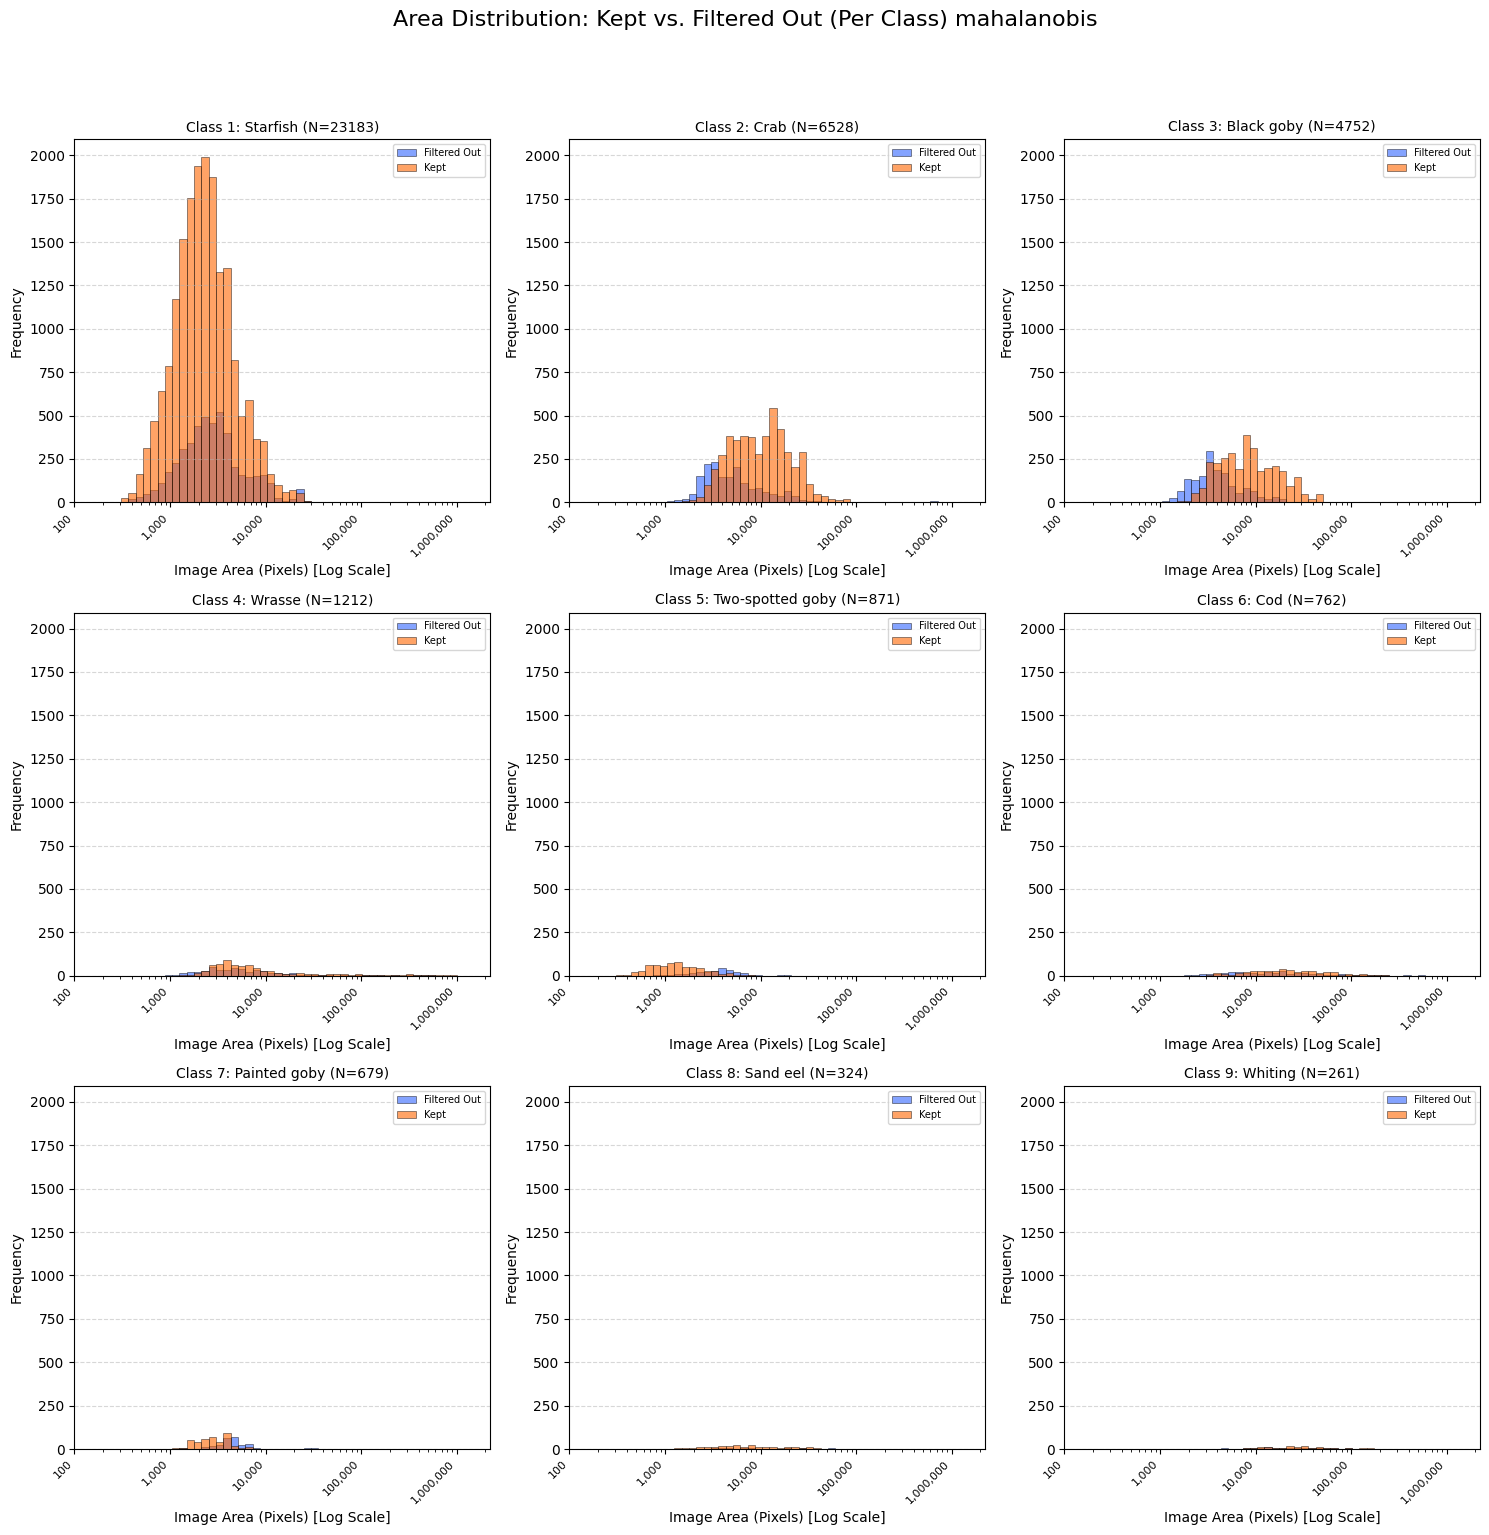

In [27]:

# 2. Plot the comparative histograms
plot_filtered_area_histograms(area_data_by_status_mahala, filter_type="mahalanobis")


✅ Comparative multi-histogram saved to: area_histograms_kept_vs_deleted_per_class.png


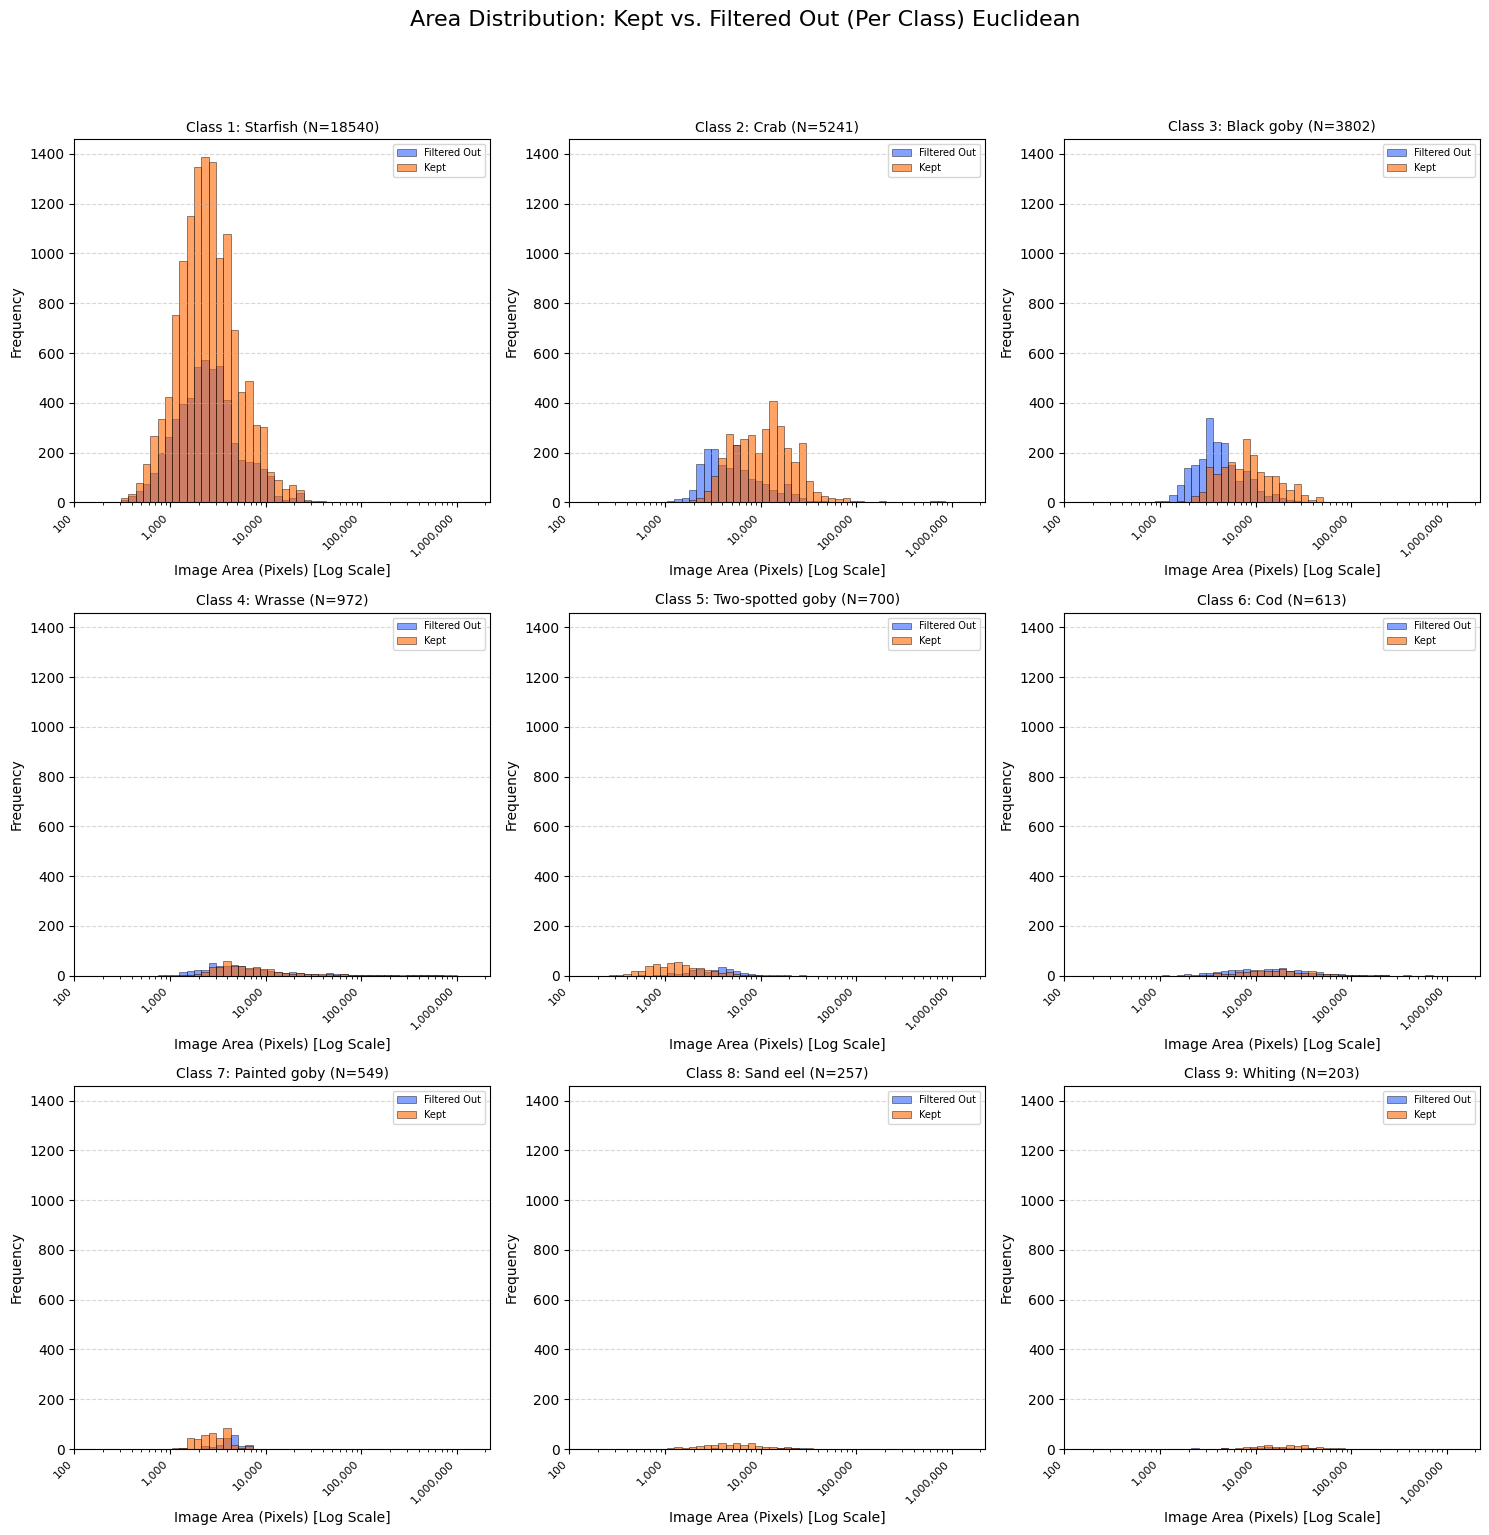

In [28]:
# 2. Plot the comparative histograms
plot_filtered_area_histograms(area_data_by_status_eu, filter_type="Euclidean")

In [29]:
def plot_filtered_area_histograms_2(area_data, filter_type, N_BINS=50):
    """
    Plots the overlapping area histograms of kept vs. deleted images for each class.
    
    MODIFIED: Each subplot now has its OWN Y-axis scale (not shared).
    """
    
    unique_classes = sorted(area_data.keys())
    if not unique_classes:
        print("Error: No data found for plotting.")
        return

    # 1. Determine Global Bins (X-Axis)
    all_areas = []
    
    for cls in unique_classes:
        kept_areas = np.array(area_data[cls]['kept'])
        deleted_areas = np.array(area_data[cls]['deleted'])
        
        if kept_areas.size > 0 or deleted_areas.size > 0:
            all_areas.append(np.concatenate([kept_areas, deleted_areas]))

    if not all_areas:
         print("Error: Combined area data is empty. Cannot plot.")
         return
         
    combined_data = np.concatenate(all_areas)

    # Define Global Logarithmic Bins (Shared X-axis)
    min_area = np.min(combined_data[combined_data > 0])
    MAX_X_LIMIT = 2000000
    
    # Define bins up to the max limit
    bin_edges = np.logspace(np.log10(min_area), np.log10(MAX_X_LIMIT), N_BINS + 1)
    
    # **Removed the calculation of max_frequency (Global Y-axis)**


    # 2. Set up Subplots
    n_classes = len(unique_classes)
    n_cols = int(np.ceil(np.sqrt(n_classes)))
    n_rows = int(np.ceil(n_classes / n_cols))

    # sharex=True: Keep X-axis scales identical
    # sharey=False: Allow EACH subplot to determine its own Y-axis scale (Default, but explicit for clarity)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15), sharex=True, sharey=False) 
    fig.suptitle(f"Area Distribution: Kept vs. Filtered Out - {filter_type}", fontsize=16, y=1.02)
    axes_flat = axes.flatten()

    # Define X-Axis Ticks (Using np.floor for accurate MAX_X_LIMIT)
    # The max power of 10 must be <= MAX_X_LIMIT
    start_power = int(np.floor(np.log10(min_area)))
    end_power = int(np.floor(np.log10(MAX_X_LIMIT))) 
    log_ticks = [10**i for i in range(start_power, end_power + 1)]
    if MAX_X_LIMIT not in log_ticks:
        log_ticks.append(MAX_X_LIMIT)
    log_labels = [f'{t:,}' for t in log_ticks]
    x_label = "Image Area (Pixels) [Log Scale]"

    # 3. Plotting Loop
    for i, cls in enumerate(unique_classes):
        ax = axes_flat[i]
        
        # Clip data to MAX_X_LIMIT before plotting
        kept_areas = np.clip(area_data[cls]['kept'], a_min=None, a_max=MAX_X_LIMIT)
        deleted_areas = np.clip(area_data[cls]['deleted'], a_min=None, a_max=MAX_X_LIMIT)
        
        if kept_areas.size == 0 and deleted_areas.size == 0:
            ax.set_title(f"Class {cls} ({LABEL_MAP.get(cls, 'Unknown')})\nNo Data (N=0)", fontsize=10)
            ax.axis('off')
            continue
            
        # Plot DELETED (Red)
        ax.hist(
            deleted_areas, 
            bins=bin_edges, 
            label='Filtered Out', 
            color=BRIGHT_COLORS[2], # blue
            alpha=0.6, 
            edgecolor='black', 
            linewidth=0.5
        )
        
        # Plot KEPT (Green)
        ax.hist(
            kept_areas, 
            bins=bin_edges, 
            label='Kept', 
            color=BRIGHT_COLORS[6], # orange
            alpha=0.6, 
            edgecolor='black', 
            linewidth=0.5
        )
        
        # Set X-axis properties (Shared, forced visibility)
        ax.set_xscale('log')
        ax.set_xlim(left=min_area, right=MAX_X_LIMIT)
        
        # **Removed: ax.set_ylim(0, max_frequency * 1.05) - Y-limit is now auto-scaled**
        
        # Add legend to each plot
        if kept_areas.size > 0 or deleted_areas.size > 0:
            ax.legend(fontsize=7, loc='upper right')
        
        # Force X-tick labels to show on all plots (from previous fix)
        ax.set_xticks(log_ticks)
        ax.set_xticklabels(log_labels, rotation=45, ha='right', fontsize=8)
        ax.set_xlabel(x_label, fontsize=10)
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
        
        # Set Y-label on every plot
        ax.set_ylabel("Frequency", fontsize=10)
        
        total_n = len(kept_areas) + len(deleted_areas)
        ax.set_title(f"Class {cls}: {LABEL_MAP.get(cls, 'Unknown')} (N={total_n})", fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Turn off any unused subplots
    for i in range(n_classes, n_rows * n_cols):
        if i < len(axes_flat):
            fig.delaxes(axes_flat[i])
        
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    output_path = f"area_histograms_kept_vs_deleted_per_class_independent_y_{filter_type}.png"
    plt.savefig(output_path)
    print(f"\n✅ Comparative multi-histogram saved to: {output_path}")


✅ Comparative multi-histogram saved to: area_histograms_kept_vs_deleted_per_class_independent_y_Mahalanobis.png


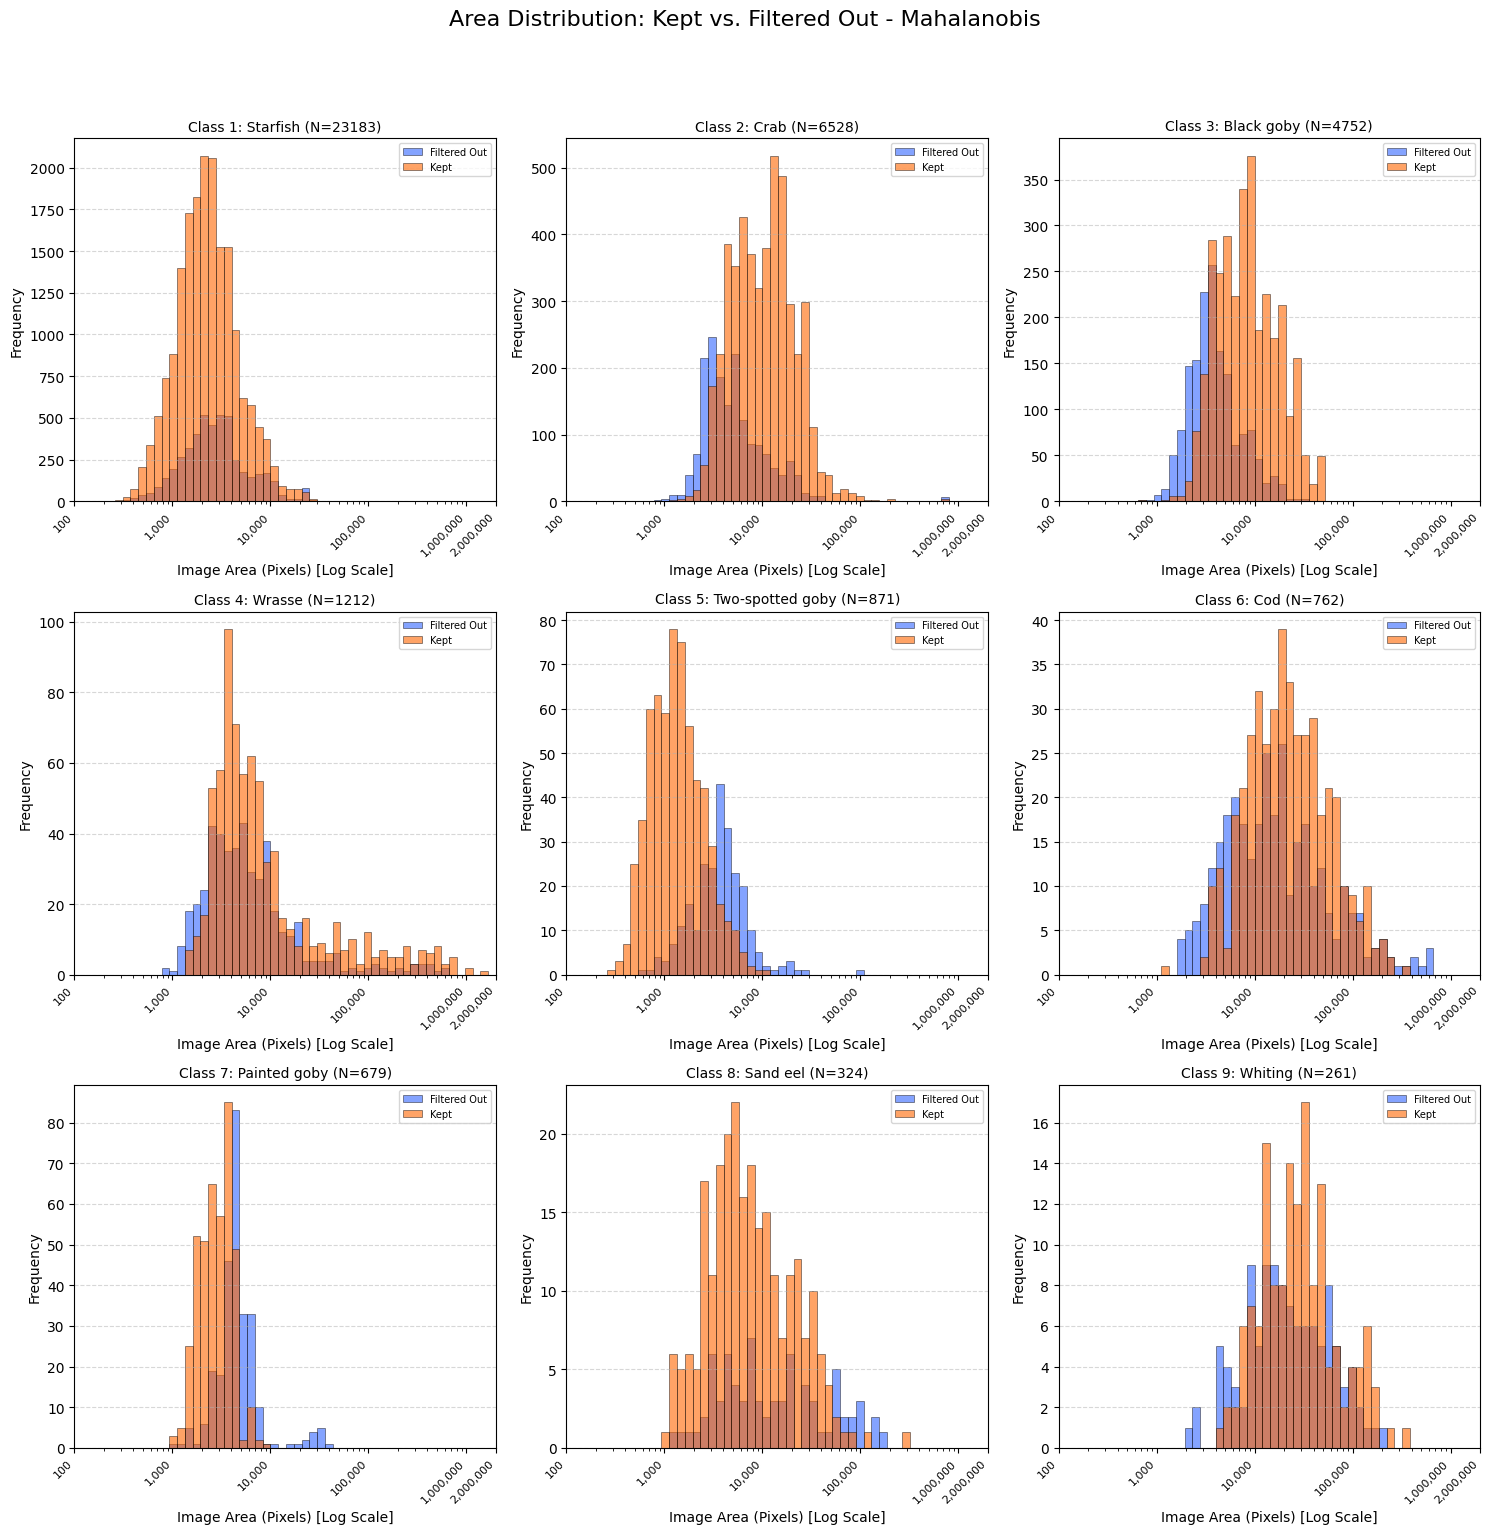

In [30]:
plot_filtered_area_histograms_2(area_data_by_status_mahala, filter_type="Mahalanobis")


✅ Comparative multi-histogram saved to: area_histograms_kept_vs_deleted_per_class_independent_y_Euclidean.png


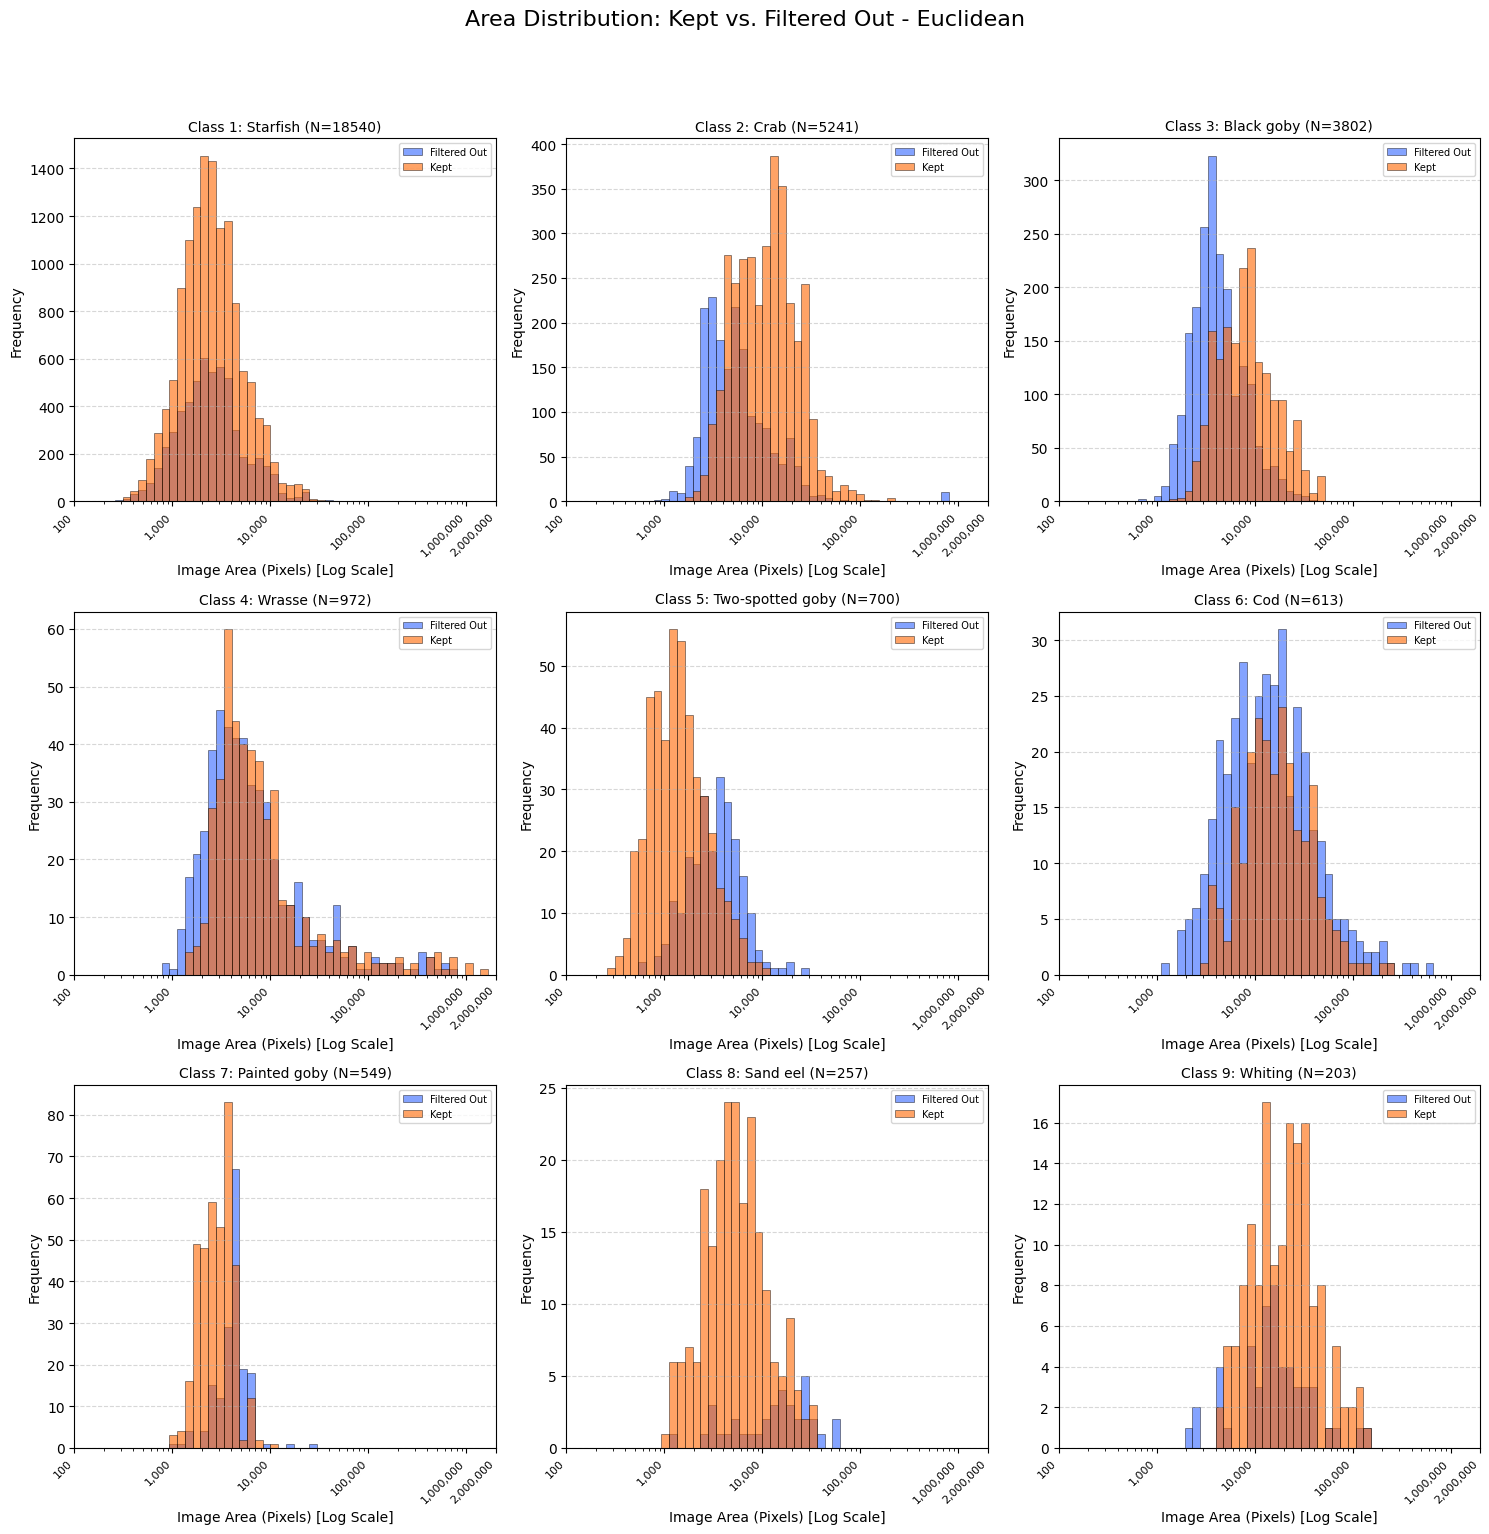

In [31]:
plot_filtered_area_histograms_2(area_data_by_status_eu, filter_type="Euclidean")

In [33]:
def plot_filtered_area_histograms_1x9(area_data,filter_type, N_BINS=50, USE_LOG_SCALE=True):
    """
    Plots the overlapping area histograms of kept vs. deleted images for each class 
    in a 1 column, N rows layout with independent Y-axes and X-ticks visible on ALL plots.
    """
    
    unique_classes = sorted(area_data.keys())
    n_classes = len(unique_classes)
    if not unique_classes:
        print("Error: No data found for plotting.")
        return

    # 2a. Determine Global Bins (for shared X-axis)
    all_areas = np.concatenate([np.concatenate([v['kept'], v['deleted']]) for v in area_data.values() if v['kept'] or v['deleted']])
    
    if all_areas.size == 0:
         print("Error: Combined area data is empty. Cannot plot.")
         return

    min_area = np.min(all_areas[all_areas > 0])
    max_area = np.max(all_areas)
    bin_edges = np.logspace(np.log10(min_area), np.log10(max_area), N_BINS + 1)
    
    # 2b. Set up Subplots (1 Column, N Rows)
    n_rows = n_classes
    n_cols = 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 4 * n_rows), sharex=True, sharey=False)
    fig.suptitle(f"Area Distribution: Kept vs. Filtered Out (Independent Y-Scales)- {filter_type}", fontsize=16, y=0.995)
    
    axes_flat = axes.flatten()
    MAX_X_LIMIT = 2000000
    # Define X-Axis Ticks (Logarithmic)
    log_ticks = [10**i for i in range(int(np.floor(np.log10(min_area))), int(np.floor(np.log10(MAX_X_LIMIT))) + 1)]
    log_labels = [f'{t:,}' for t in log_ticks]
    x_label = "Image Area (Pixels) [Log Scale]"

    # 2c. Plotting Loop
    for i, cls in enumerate(unique_classes):
        ax = axes_flat[i]
        kept_areas = area_data[cls]['kept']
        deleted_areas = area_data[cls]['deleted']
        
        if not kept_areas and not deleted_areas:
            ax.set_title(f"Class {cls} ({LABEL_MAP.get(cls, 'Unknown')})\nNo Data (N=0)", fontsize=10)
            ax.axis('off')
            continue
            
        # Plotting the two overlapping histograms
        ax.hist(
            [deleted_areas, kept_areas], # Plotting two datasets at once
            bins=bin_edges, 
            label=['Filtered Out', 'Kept'], 
            color=[BRIGHT_COLORS[2], BRIGHT_COLORS[6]], # Red then Green
            alpha=0.6, 
            edgecolor='black', 
            linewidth=0.5
        )
        
        # Set shared X properties
        ax.set_xscale('log')
        
        # *** KEY CHANGE: Show X-tick labels for all plots ***
        ax.set_xticks(log_ticks)
        ax.set_xticklabels(log_labels, rotation=45, ha='right', fontsize=9)
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
       
        ax.set_xlabel(x_label, fontsize=11)
        
            

        # Y-axis labels and titles
        ax.set_ylabel("Frequency", fontsize=10)
        ax.set_title(f"Class {cls}: {LABEL_MAP.get(cls, 'Unknown')} (N={len(kept_areas) + len(deleted_areas)})", fontsize=12)
        
        # Add legend to each plot
        if kept_areas or deleted_areas:
            ax.legend(fontsize=8, loc='upper right')
        
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Turn off any unused subplots
    for i in range(n_classes, n_rows * n_cols):
        fig.delaxes(axes_flat[i])
        
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    output_path = "area_histograms_kept_vs_deleted_1xN_all_xticks.png"
    plt.savefig(output_path)
    print(f"\n✅ Comparative multi-histogram saved to: {output_path}")


✅ Comparative multi-histogram saved to: area_histograms_kept_vs_deleted_1xN_all_xticks.png


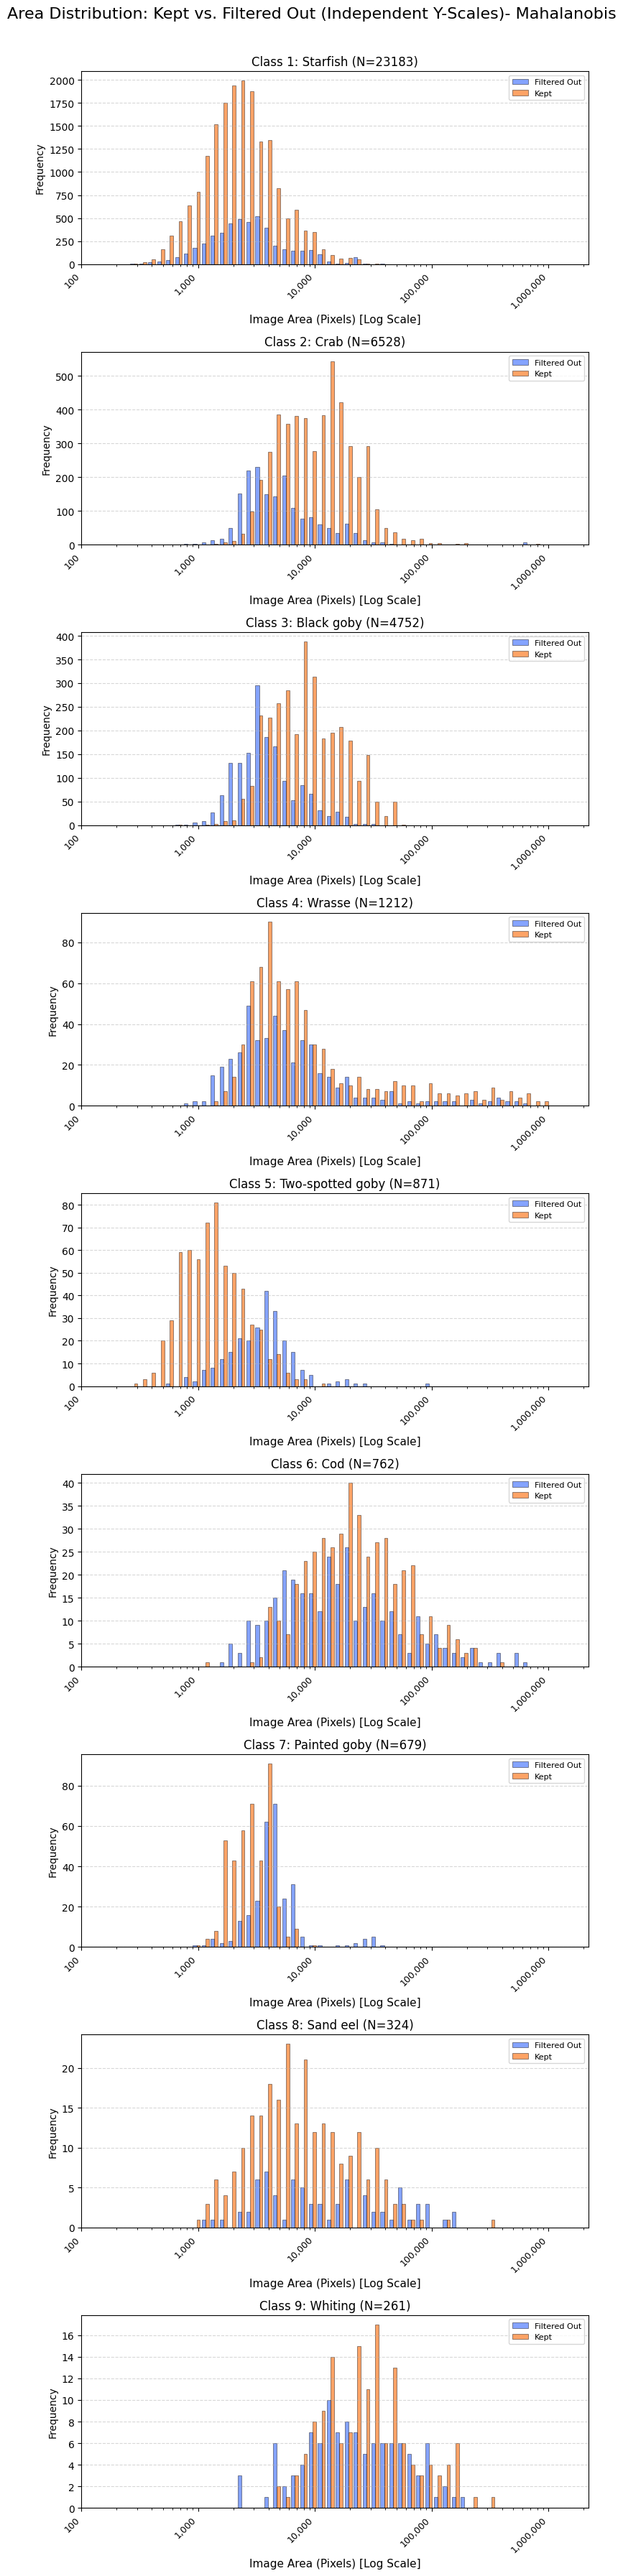

In [34]:


plot_filtered_area_histograms_1x9(area_data_by_status_mahala, filter_type="Mahalanobis")



✅ Comparative multi-histogram saved to: area_histograms_kept_vs_deleted_1xN_all_xticks.png


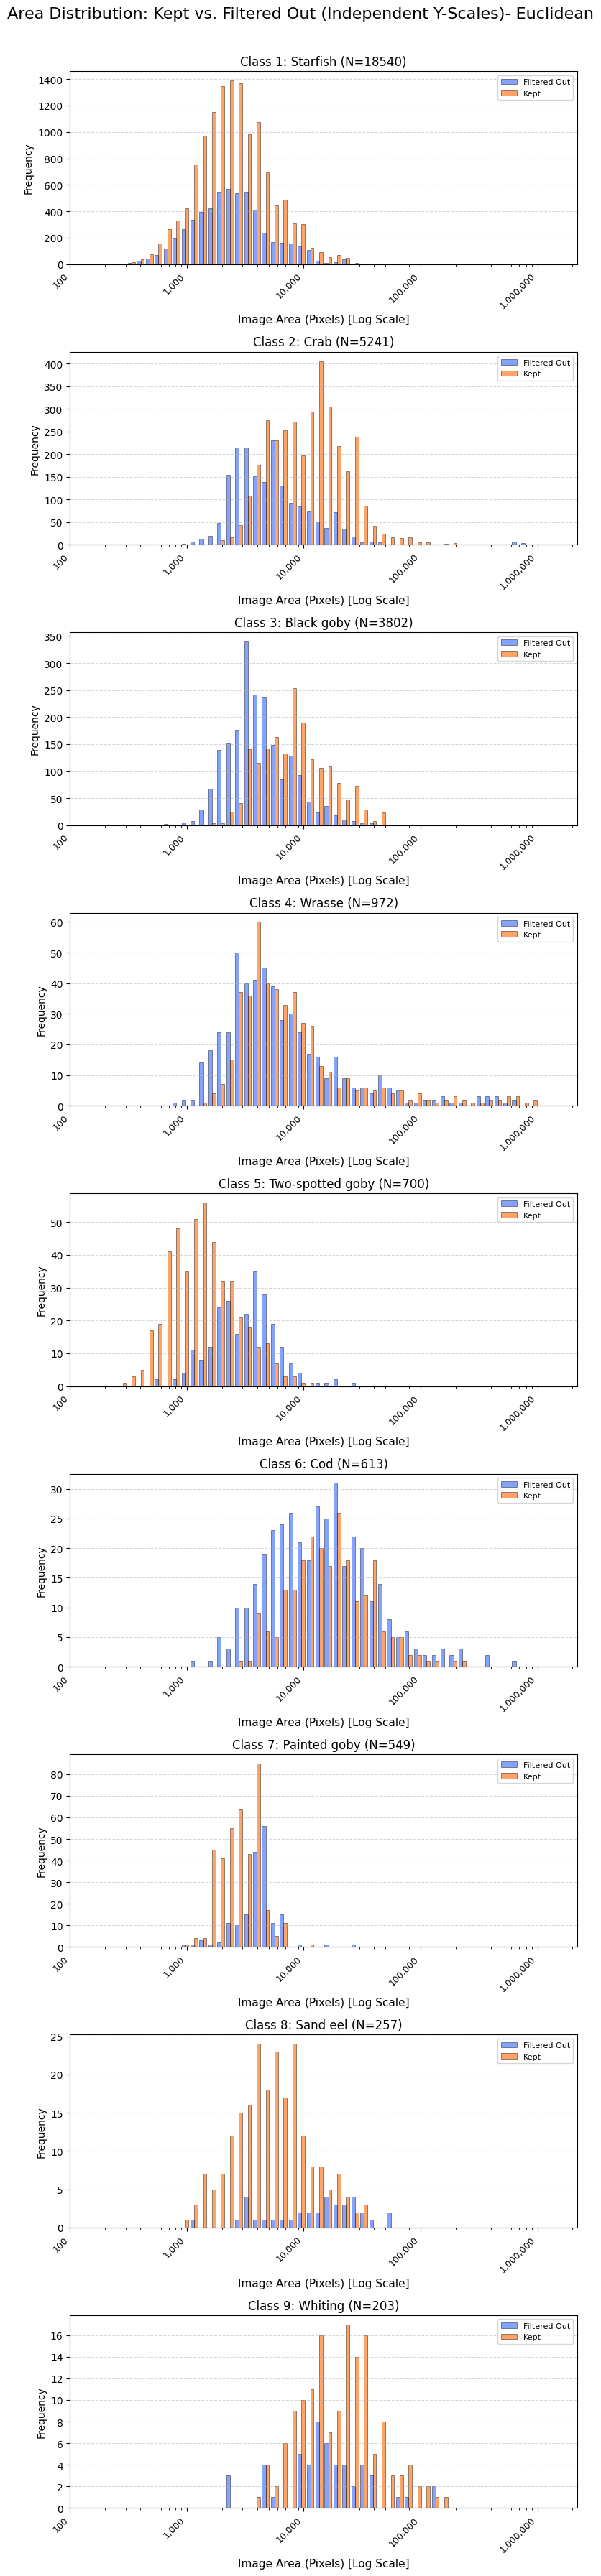

In [35]:
plot_filtered_area_histograms_1x9(area_data_by_status_eu, filter_type="Euclidean")